In [3]:
import time
import statistics

def bucket_sort(arr):
    n = len(arr)

    if n == 0:
        return []

    buckets = [[] for _ in range(n)]

    # Distribute elements into buckets
    for value in arr:
        index = min(int(value * n), n - 1)
        buckets[index].append(value)

    # Sort each bucket
    for bucket in buckets:
        bucket.sort()

    # Merge buckets
    result = []
    for bucket in buckets:
        result.extend(bucket)

    return result


sizes = list(range(100, 10001, 500))
times = []
runs = 5

for n in sizes:
    # Fixed deterministic values in [0, 1)
    arr = [((i * 37) % n) / n for i in range(n)]

    measurements = []

    for _ in range(runs):
        start = time.perf_counter_ns()
        bucket_sort(arr)
        end = time.perf_counter_ns()

        measurements.append(end - start)

    times.append(statistics.median(measurements))

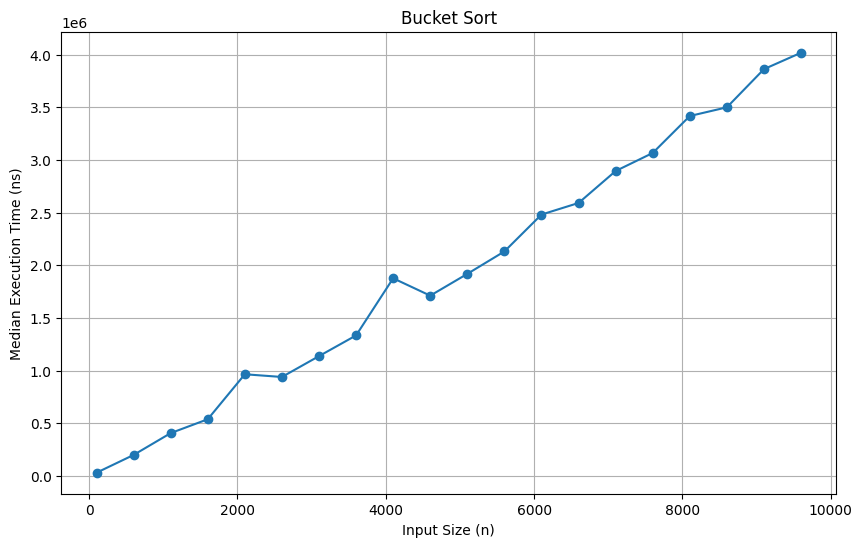

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o')
plt.title("Bucket Sort")
plt.xlabel("Input Size (n)")
plt.ylabel("Median Execution Time (ns)")
plt.grid(True)
plt.show()